In [23]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
import nltk
from nltk.stem import WordNetLemmatizer
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet", quiet=True)
lemmatizer = WordNetLemmatizer()
import joblib
from sklearn.model_selection import train_test_split
from collections import Counter

In [24]:
#  Step1. LOAD DATASET

# Load cả hai file
df_raw = pd.read_csv("emails_raw.csv")
df_extra = pd.read_csv("email_raw1.csv")

# Cột trong email_text.csv là label => đổi tên cho giống
df_extra = df_extra.rename(columns={"label": "spam"})

# Lấy chỉ các email spam từ file bổ sung
spam_extra = df_extra[df_extra["spam"] == 1]

# Chọn 2700 email spam
spam_sample = spam_extra.sample(n=2700, random_state=42)

# Gộp với dữ liệu gốc
df_combined = pd.concat([df_raw, spam_sample], ignore_index=True)

# Xóa trùng text sau khi gộp
df_combined = df_combined.drop_duplicates(subset=["text"]).reset_index(drop=True)

# Lưu file mới
df_combined.to_csv("emails_balanced.csv", index=False)


------------ Missing Data ------------
text    0
spam    0
dtype: int64

------------ Duplicate emails ------------
Shape before: (8395, 2)
Duplicate rows: 0
Shape after removing duplicates: (8395, 2)

------------ Label Check ------------
Counts:
spam
0    4327
1    4068
Name: count, dtype: int64

Percentages:
Class 0: 51.54%
Class 1: 48.46%


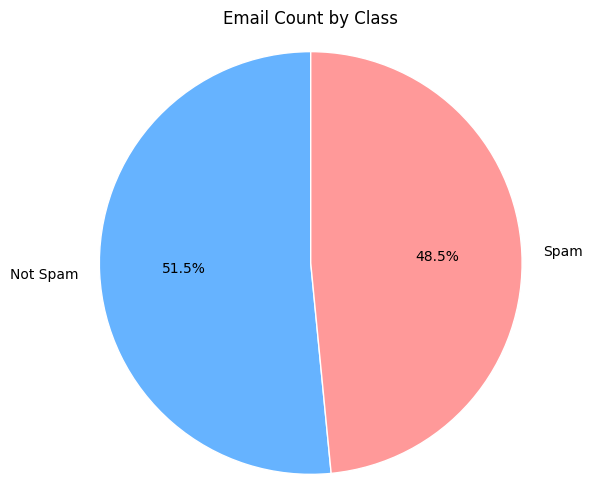

In [25]:
# Step2. DATA QUALITY CHECK

# 2.1 Missing data
print("------------ Missing Data ------------")
print(df_combined.isnull().sum())
if df_combined.isnull().values.any():
    df_combined = df_combined.dropna() #dùng để xoá dòng bị thiếu data

# 2.2 Duplicate emails
print("\n------------ Duplicate emails ------------")
print("Shape before:", df_combined.shape)

print("Duplicate rows:", df_combined.duplicated().sum())
df_combined = df_combined.drop_duplicates()

print("Shape after removing duplicates:", df_combined.shape)

# 2.3 Check label có cân bằng không (vì nếu quá lệch nhau => accuracy bị ảnh hưởng)
print("\n------------ Label Check ------------")
counts = df_combined["spam"].value_counts()

percent = df_combined["spam"].value_counts(
    normalize=True
) * 100

print("Counts:")
print(counts)

print("\nPercentages:")
for label, p in percent.items():
    print(f"Class {label}: {p:.2f}%")


# Visualize: Pie chart Email Count by Class
counts = df_combined["spam"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["Not Spam", "Spam"],
    autopct="%.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999"],
    wedgeprops={"edgecolor": "white"}
)

plt.title("Email Count by Class")
plt.axis("equal")
plt.show()


In [26]:
# Step3. TEXT PREPROCESSING

def clean(text):
    # Chuyển toàn bộ thành chữ thường
    text = text.lower()
    # Remove email reply prefixes (tiền tố)
    text = re.sub(
        r'((re|fw|fwd)\s*:)+',
        ' ',
        text
    )

    # remove "subject:"
    text = re.sub(
        r'subject\s*:',
        ' ',
        text
    )
    # Xoá URL 
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ',
        text
    )

    # Xoá phần http / https còn sót lại
    text = re.sub(
        r'\bhttps?\b',
        ' ',
        text
    )
    # Xóa HTML tags
    text = re.sub(r'<.*?>',' ',text)
    # Xoá mọi thứ KHÔNG phải chữ cái
    text = re.sub(r'[^a-zA-Z ]',' ',text)
    # Dọn khoảng trắng thừa
    text = re.sub(r'\s+',' ',text).strip()

    # Loại stopword tiếng Anh và chuẩn hóa động từ về dạng gốc
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS and len(word) > 3]
    words = [lemmatizer.lemmatize(word, pos='v') for word in words]
    text = ' '.join(words)

    return text


df_combined["text"] = df_combined["text"].apply(clean)
df_combined.to_csv("balance_emails_cleaned.csv", index=False)

# remove blank emails after cleaning
df_combined = df_combined[df_combined["text"].str.strip() != ""]

# remove duplicates after cleaning
df_combined = df_combined.drop_duplicates(subset=["text"])

# Double check
print("Blank rows:",
      (df_combined["text"] == "").sum())

print("Duplicate texts:",
      df_combined["text"].duplicated().sum())
df_combined.to_csv("balance_emails_cleaned.csv", index=False)

Blank rows: 0
Duplicate texts: 0


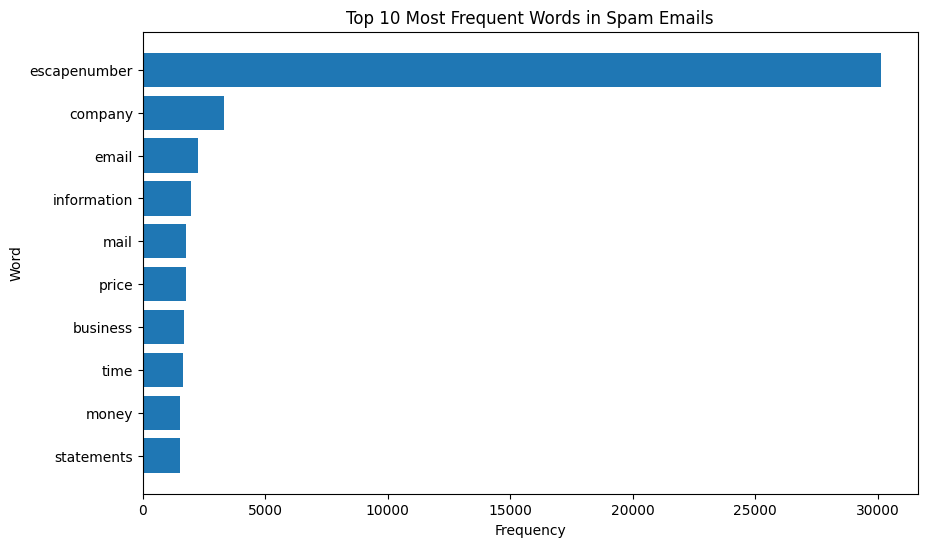

In [28]:
# VISUALIZE AFTER CLEANING
# 3.1 Top 10 Words in Spam Emails

spam_text = " ".join(
    df_combined[df_combined["spam"] == 1]["text"].astype(str)
)

spam_words = spam_text.split()

top_spam_words = pd.DataFrame(
    Counter(spam_words).most_common(10),
    columns=["Word", "Frequency"]
)

top_spam_words

# Visualization
plt.figure(figsize=(10, 6))

plt.barh(

    top_spam_words["Word"][::-1],

    top_spam_words["Frequency"][::-1]

)

plt.title("Top 10 Most Frequent Words in Spam Emails")

plt.xlabel("Frequency")

plt.ylabel("Word")

plt.show()

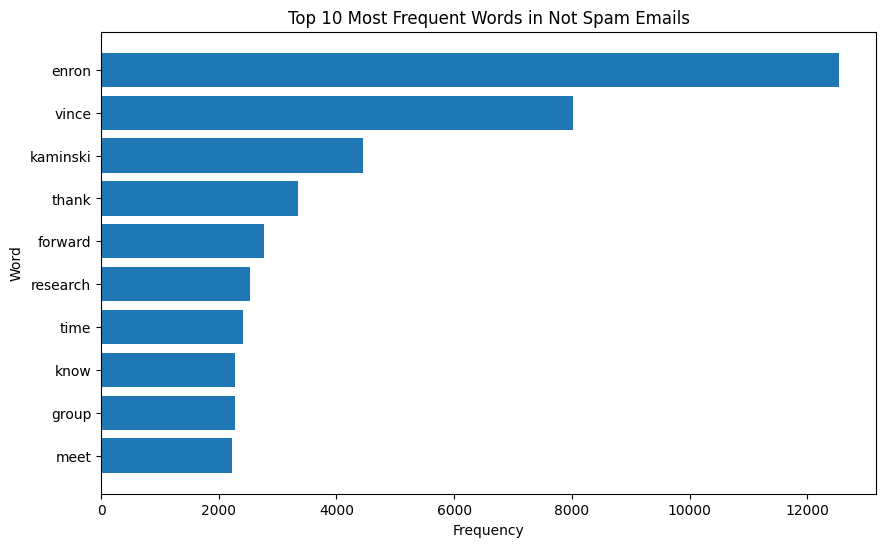

In [29]:
# VISUALIZE AFTER CLEANING
# 3.2 Top 10 Words in Not Spam Emails

ham_text = " ".join(
    df_combined[df_combined["spam"] == 0]["text"].astype(str)
)

ham_words = ham_text.split()

top_ham_words = pd.DataFrame(
    Counter(ham_words).most_common(10),
    columns=["Word", "Frequency"]
)

top_ham_words

# Visualization

plt.figure(figsize=(10, 6))
plt.barh(
    top_ham_words["Word"][::-1],
    top_ham_words["Frequency"][::-1]
)

plt.title("Top 10 Most Frequent Words in Not Spam Emails")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [30]:
# Step4. FEATURE ENGINEERING
df_combined["email_length"] = df_combined["text"].str.len()

In [31]:
# 4.1 Basic Statistics

print("===== Email Length Statistics =====")

print(df_combined["email_length"].describe())

===== Email Length Statistics =====
count     8181.000000
mean       838.318421
std       1222.895072
min          4.000000
25%        243.000000
50%        458.000000
75%        943.000000
max      25222.000000
Name: email_length, dtype: float64


In [32]:
# 4.2 Compare average email length by class

print("\n===== Mean Email Length By Class =====")

print(
    df_combined.groupby("spam")
      ["email_length"]
      .mean()
)


===== Mean Email Length By Class =====
spam
0    833.512485
1    843.206114
Name: email_length, dtype: float64


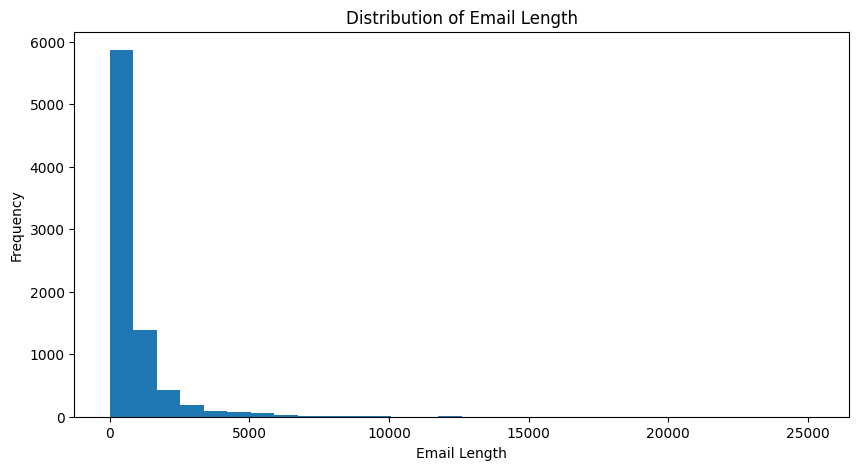

In [33]:
# 4.3 HISTOGRAM: thể hiện phân bố độ dài email cho cả dataset

plt.figure(figsize=(10,5))

plt.hist(df_combined["email_length"], bins=30)

plt.title("Distribution of Email Length")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

In [34]:
# 4.4 Skewness

print(
    "Skewness:",
    df_combined["email_length"].skew()
)

Skewness: 5.859462896902222


In [35]:
# 4.5 Group Statistic: riêng cho từng class spam/ham

print(
    df_combined.groupby("spam")["email_length"]
      .describe()
)

       count        mean          std   min    25%    50%      75%      max
spam                                                                       
0     4125.0  833.512485  1110.645303  14.0  275.0  540.0  1004.00  25222.0
1     4056.0  843.206114  1327.475160   4.0  208.0  388.0   827.75  18359.0


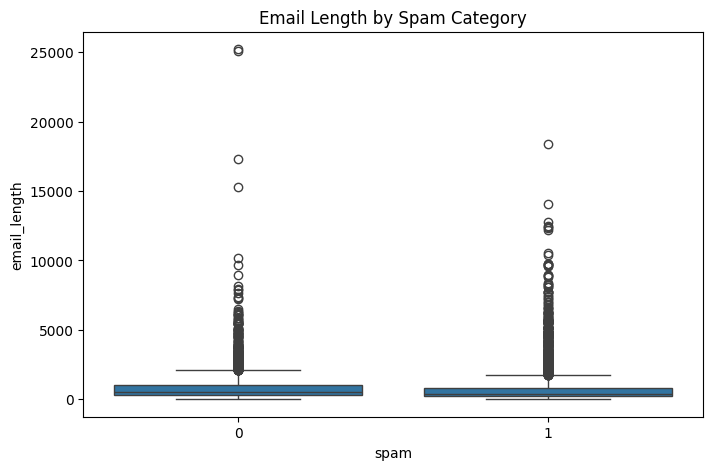

In [36]:
# 4.6 Boxplot

plt.figure(figsize=(8,5))

sns.boxplot(
    x="spam",
    y="email_length",
    data=df_combined
)

plt.title(
    "Email Length by Spam Category"
)

plt.show()

In [17]:
# 4.7 Outlier Detection - IQR

Q1 = df_combined["email_length"].quantile(0.25)

Q3 = df_combined["email_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_combined[
    (df_combined["email_length"] < lower_bound)
    |
    (df_combined["email_length"] > upper_bound)
]

print("IQR Outliers:", len(outliers))


IQR Outliers: 713


In [37]:
# 4.8 Outlier Detection - Z Score

mean = df_combined["email_length"].mean()

std = df_combined["email_length"].std()

z_scores = (df_combined["email_length"] - mean) / std

outliers_z = (abs(z_scores) > 3).sum()

print("Z-score Outliers:", outliers_z)

Z-score Outliers: 190


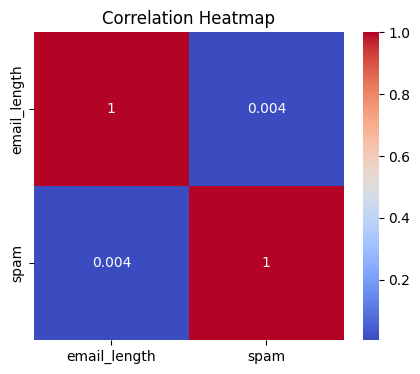

In [38]:
# 4.9 Heatmap

corr = df_combined[
    ["email_length", "spam"]
].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [39]:
# 4.10 VOCABULARY ANALYSIS
# Count unique words before vectorization

all_words = " ".join(
    df_combined["text"]
).split()

unique_words = set(
    all_words
)

print("Total words:", len(all_words))

print("Unique words:", len(unique_words))

Total words: 886724
Unique words: 55882


In [40]:
# Step5. CHIA TRAIN/TEST
X = df_combined["text"]
y = df_combined["spam"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #cố định cách chia
    stratify=y #cố định tỉ lệ spam/ham ở train và test giống tỉ lệ của dataset
)
print("Train samples:", len(X_train_text))
print("Test samples:", len(X_test_text))

# Lưu train / test chưa vector
train_df = pd.DataFrame({
    "text": X_train_text.values,   #.values để tránh mismatch index (tránh tạo dataframe với index lung tung)
    "spam": y_train.values
})

test_df = pd.DataFrame({
    "text": X_test_text.values,
    "spam": y_test.values
})

train_df.to_csv("train_balance.csv", index=False)
test_df.to_csv("test_balance.csv", index=False)

Train samples: 6544
Test samples: 1637


In [41]:
# Step6. VECTORIZATION: Chuyển text → số

vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2, #document frequency: chỉ giữ từ xuất hiện ít nhất 2 emails
    ngram_range=(1,2),
    token_pattern=r'\b\w{4,}\b' #ít nhất 4 kí tự
)
X_train = vectorizer.fit_transform(X_train_text)

X_test = vectorizer.transform(X_test_text)
# in shape
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Lưu vectorizer
joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)
print("Vectorizer saved!")

# lưu feature count để debug
print(
    "Vocabulary size:",
    len(vectorizer.vocabulary_)
)

# lưu data sau khi vectorize
joblib.dump(X_train, "X_train_balance.pkl")
joblib.dump(X_test, "X_test_balance.pkl")

joblib.dump(y_train, "y_train_balance.pkl")
joblib.dump(y_test, "y_test_balance.pkl")

Train shape: (6544, 10000)
Test shape: (1637, 10000)
Vectorizer saved!
Vocabulary size: 10000


['y_test_balance.pkl']